<a href="https://colab.research.google.com/github/greensky0107/self_study/blob/main/Day50_DeepLearningModel_Layer%26ModelComponent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5-2.딥러닝 구조와 층(Layer)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
keras.Input(shape=(8,), dtype=tf.int32)

<KerasTensor shape=(None, 8), dtype=int32, sparse=False, name=keras_tensor>

In [ ]:
keras.Input(shape=(28, 28), dtype=tf.float32)

<KerasTensor shape=(None, 28, 28), dtype=float32, sparse=False, name=keras_tensor_1>

In [ ]:
# Input 객체는 batch_size로 크기지정및, name을 통해서 이름을 지정가능
keras.Input(shape=(28, 28), dtype=tf.float32, batch_size=16)

<KerasTensor shape=(16, 28, 28), dtype=float32, sparse=False, name=keras_tensor_2>

In [ ]:
keras.Input(shape=(28, 28), dtype=tf.float32, batch_size=16, name='input')

<KerasTensor shape=(16, 28, 28), dtype=float32, sparse=False, name=input>

In [ ]:
layers.Dense(10)

<Dense name=dense_1, built=False>

In [ ]:
# 이름 지정
layers.Dense(10, name='layer1')

<Dense name=layer1, built=False>

In [ ]:
# 활성화 함수지정 softmax
layers.Dense(10, activation='softmax')

In [ ]:
# 활성화 함수지정 relu, 이름 지정 Dense Layer
layers.Dense(10, activation='relu', name='Dense Layer')

<Dense name=Dense Layer, built=False>

In [ ]:
inputs = tf.random.uniform(shape=(5, 2))
print(inputs)
layer = layers.Dense(10, activation='relu')
outputs = layer(inputs)
print(layer.weights)
print(layer.bias)
print(outputs)

tf.Tensor(
[[0.38837302 0.25157475]
 [0.96288645 0.43968058]
 [0.3610326  0.7225114 ]
 [0.39707994 0.32306445]
 [0.50926733 0.6998036 ]], shape=(5, 2), dtype=float32)
[<Variable path=dense_2/kernel, shape=(2, 10), dtype=float32, value=[[-0.34640443 -0.11862886 -0.54739904 -0.47807944 -0.57873845 -0.40376544
   0.08239996  0.4756269  -0.0124318   0.60182744]
 [-0.23780045  0.10165548 -0.5594682  -0.65574443 -0.43360323  0.44158572
   0.36742765 -0.04632425 -0.5803965   0.70620006]]>, <Variable path=dense_2/bias, shape=(10,), dtype=float32, value=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]>]
<Variable path=dense_2/bias, shape=(10,), dtype=float32, value=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]>
tf.Tensor(
[[0.         0.         0.         0.         0.         0.
  0.12443744 0.17306663 0.         0.41139564]
 [0.         0.         0.         0.         0.         0.
  0.2408926  0.4376068  0.         0.88999397]
 [0.         0.03061836 0.         0.         0.         0.17327823
  0.29521975 0.13824701 0.

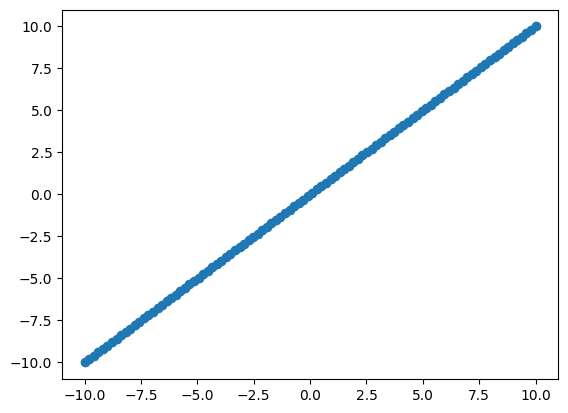

In [ ]:
# Activation Layer
import numpy as np
import matplotlib.pyplot as plt

input = np.linspace(-10, 10, 100)
x = np.linspace(-10, 10, 100)
plt.scatter(x, input)
plt.show()

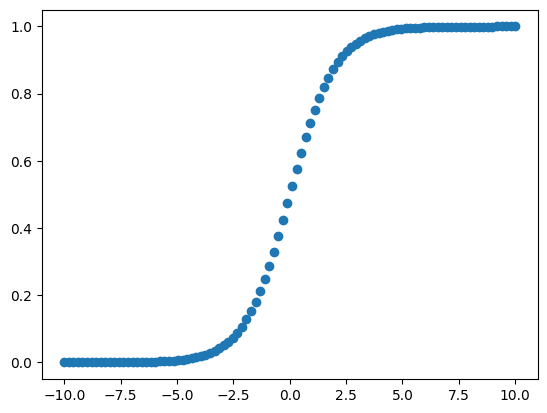

In [ ]:
# 활성화 함수 : 시그모이드 함수
layer = layers.Activation('sigmoid')
output = layer(input)

plt.scatter(x, output)
plt.show()

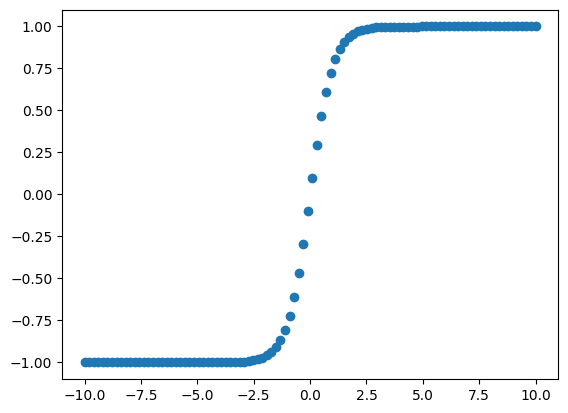

In [ ]:
# 활성화 함수 : 하이퍼 볼릭 탄젠트 함수
layer = layers.Activation('tanh')
output = layer(input)

plt.scatter(x, output)
plt.show()

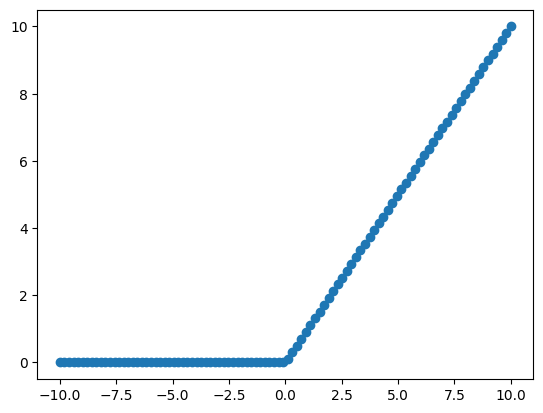

In [ ]:
# 활성화 함수 : relu
layer = layers.Activation('relu')
output = layer(input)

plt.scatter(x, output)
plt.show()

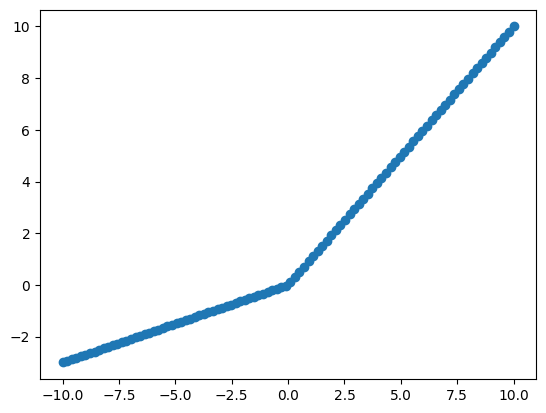

In [ ]:
# 활성화 함수 : Leaky ReLu
layer = layers.LeakyReLU()
output = layer(input)

plt.scatter(x, output)
plt.show()

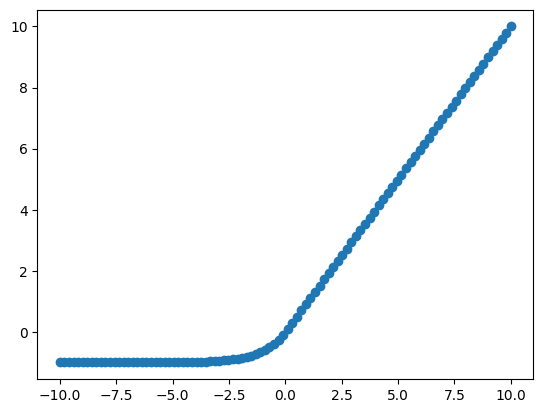

In [ ]:
# 활성화 함수 : ELU(Exponential Linear Unit)
layer = layers.ELU()
output = layer(input)

plt.scatter(x, output)
plt.show()

In [ ]:
# flatten layer 데이터를 평평하게 펴줌
inputs = keras.Input(shape=(28, 28, 1))
layer = layers.Flatten(input_shape=(28, 28, 1))(inputs)
print(layer.shape)

# 5-3.딥러닝 모델

In [ ]:
from tensorflow.keras import models, utils

In [ ]:
# Sequential API
model = models.Sequential()
model.add(layers.Input(shape=(28, 28)))
model.add(layers.Dense(300, activation='relu'))
model.add(layers.Dense(100, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 28, 300)        │         8,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 28, 100)        │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 28, 10)         │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,810 (155.51 KB)

 Trainable params: 39,810 (155.51 KB)

 Non-trainable params: 0 (0.00 B)

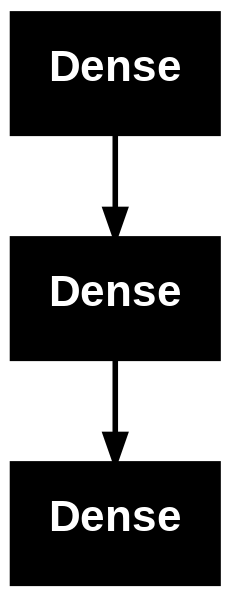

In [ ]:
# 모델 구조를 그림으로 확인
utils.plot_model(model)

In [ ]:
# Sequential 안에 모든 인자를 넣는 방법
model = models.Sequential([layers.Input(shape=(28, 28), name='Input'),
                           layers.Dense(300, activation='relu', name='Dense1'),
                           layers.Dense(100, activation='relu', name='Dense2'),
                           layers.Dense(10, activation='softmax', name='Output')])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense1 (Dense)                  │ (None, 28, 300)        │         8,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense2 (Dense)                  │ (None, 28, 100)        │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 28, 10)         │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,810 (155.51 KB)

 Trainable params: 39,810 (155.51 KB)

 Non-trainable params: 0 (0.00 B)

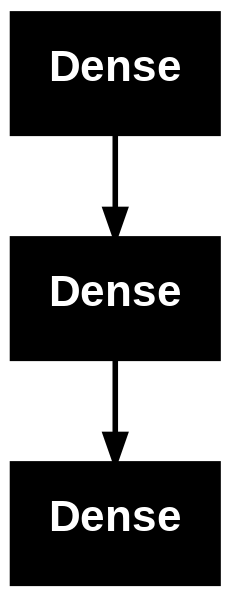

In [ ]:
utils.plot_model(model)

In [ ]:
# Functional API
inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten(input_shape=(28, 28, 1))(inputs)
x = layers.Dense(300, activation='relu')(x)
x = layers.Dense(100, activation='relu')(x)
x = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=x)
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

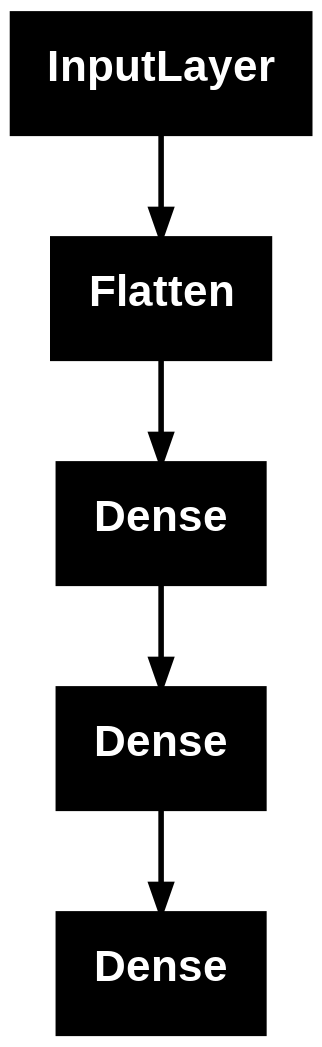

In [ ]:
utils.plot_model(model)

In [ ]:
# Functional API - Concatenate를 이용해서 Dense Layer 와 output layer 합침.
inputs = keras.Input(shape=(28, 28))
hidden1 = layers.Dense(100, activation='relu')(inputs)
hidden2 = layers.Dense(30, activation='relu')(hidden1)
concat = layers.Concatenate()([inputs, hidden2])
output = layers.Dense(1)(concat)

model = models.Model(inputs=[inputs], outputs=[output])
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 28, 100)   │      2,900 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 28, 30)    │      3,030 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 28, 58)    │          0 │ input_layer_7[0]… │
│ (Concatenate)       │                   │            │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 28, 1)     │         59 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,989 (23.39 KB)

 Trainable params: 5,989 (23.39 KB)

 Non-trainable params: 0 (0.00 B)

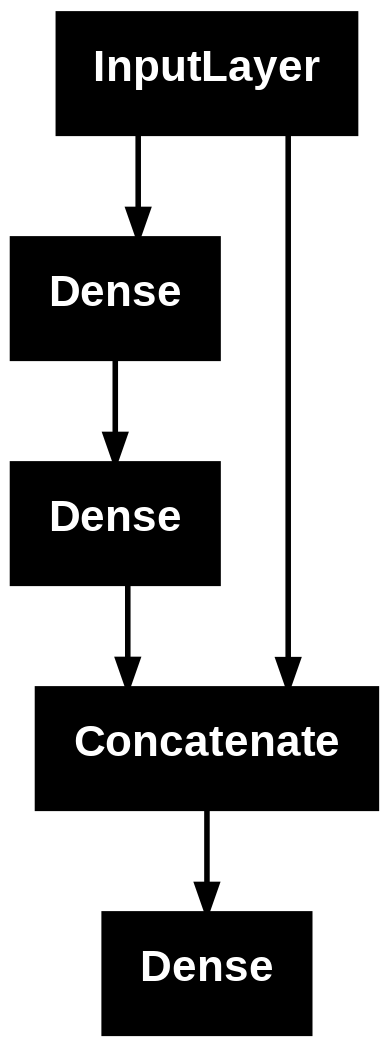

In [ ]:
utils.plot_model(model)

In [ ]:
# Functional API를 이용해서 input을 여러 개 넣는 것도 가능
input_1 = keras.Input(shape=(10, 10), name='Input_1')
input_2 = keras.Input(shape=(10, 28), name='Input_2')

hidden1 = layers.Dense(100, activation='relu')(input_2)
hidden2 = layers.Dense(10, activation='relu')(hidden1)
concat = layers.Concatenate()([input_1, hidden2])
output = layers.Dense(1, activation='sigmoid', name='output')(concat)

model = models.Model(inputs=[input_1, input_2], outputs=[output])
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_2             │ (None, 10, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 10, 100)   │      2,900 │ Input_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_1             │ (None, 10, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 10, 10)    │      1,010 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 10, 20)    │          0 │ Input_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 10, 1)     │         21 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,931 (15.36 KB)

 Trainable params: 3,931 (15.36 KB)

 Non-trainable params: 0 (0.00 B)

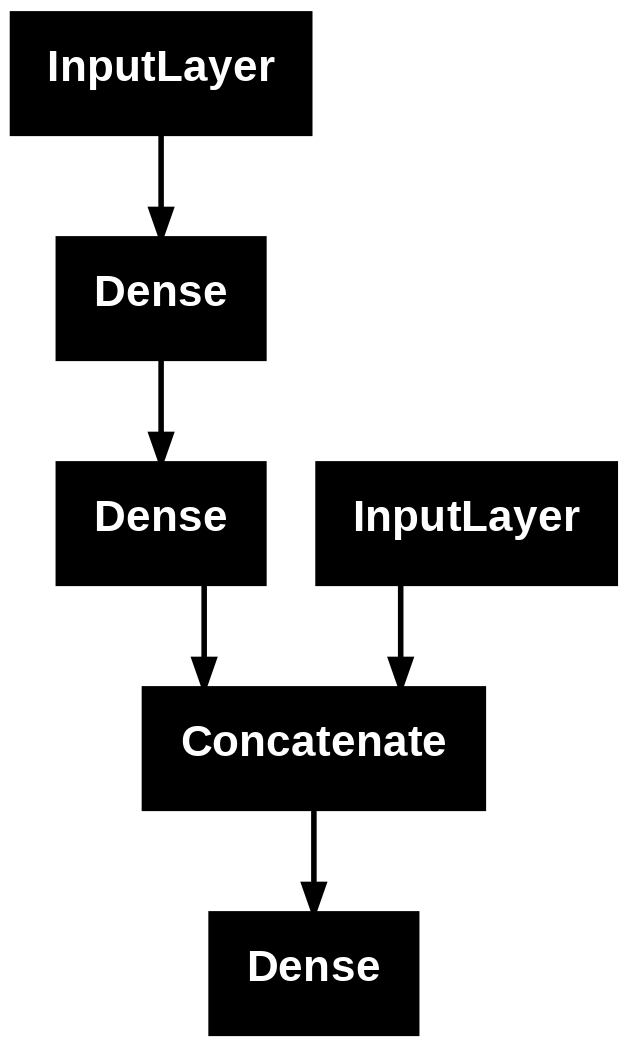

In [ ]:
utils.plot_model(model)

In [ ]:
# Functoinal API를 이용하면,  여러개 입력및 여러개 output도 가능

input_1 = keras.Input(shape=(10, 10), name='input_1')
input_2 = keras.Input(shape=(10, 28), name='input_2')
hidden1 = layers.Dense(100, activation='relu')(input_2)
hidden2 = layers.Dense(10, activation='relu')(hidden1)
concat = layers.Concatenate()([input_1, hidden2])
output = layers.Dense(1, activation='sigmoid', name='main_output')(concat)
sub_out = layers.Dense(1, name='sum_output')(hidden2)

model = models.Model(inputs=[input_1, input_2], outputs=[output, sub_out])
model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2             │ (None, 10, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 10, 100)   │      2,900 │ input_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_1             │ (None, 10, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 10, 10)    │      1,010 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 10, 20)    │          0 │ input_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ main_output (Dense) │ (None, 10, 1)     │         21 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_output (Dense)  │ (None, 10, 1)     │         11 │ dense_21[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,942 (15.40 KB)

 Trainable params: 3,942 (15.40 KB)

 Non-trainable params: 0 (0.00 B)

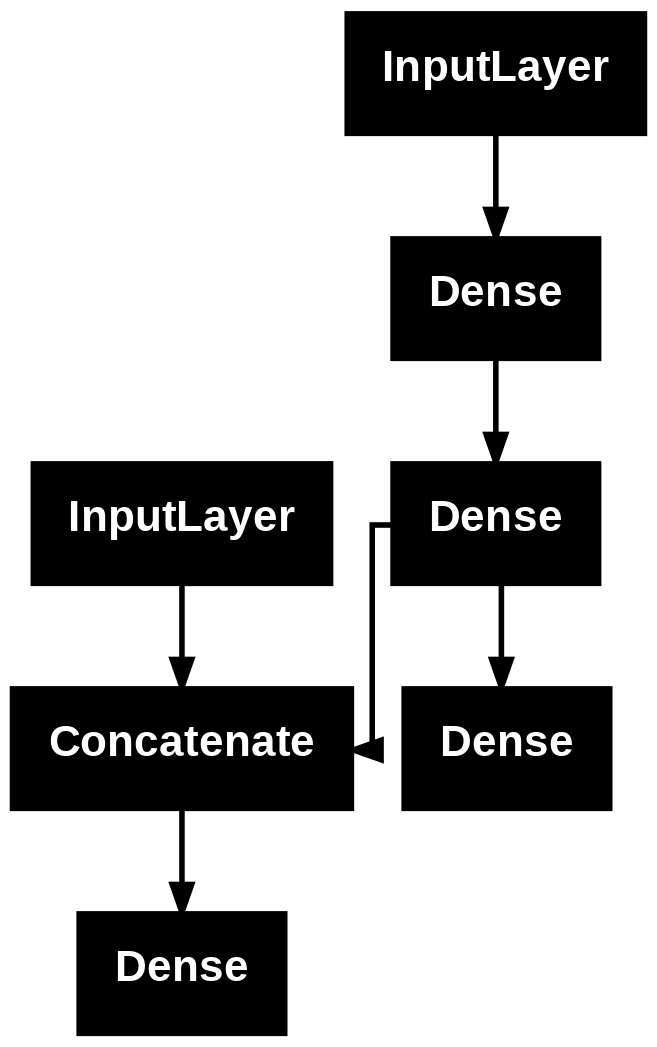

In [ ]:
utils.plot_model(model)

In [ ]:
# Subclassing API

class MyModel(models.Model):
  def __init__(self, units=30, activation='relu', **kwargs):
    super(MyModel, self).__init__(**kwargs)
    self.dense_layer1 = layers.Dense(300, activation=activation)
    self.dense_layer2 = layers.Dense(100, activation=activation)
    self.dense_layer3 = layers.Dense(units, activation=activation)
    self.output_layer = layers.Dense(10, activation='softmax')

  def call(self, inputs):
    x = self.dense_layer1(inputs)
    x = self.dense_layer2(x)
    x = self.dense_layer3(x)
    x = self.output_layer(x)
    return x

In [ ]:
# 같은 모델을  3가지 방법을 다 사용해서 만들어봄 - Sequential API
exercise_model = models.Sequential()

exercise_model.add(layers.InputLayer(input_shape=(100, 100, 3))) # (100,100,3) 형태의 데이터를 받는 input layer
exercise_model.add(layers.Flatten()) # flatten layer
exercise_model.add(layers.Dense(400, activation='relu')) # Unit의 수는 400, 활성화함수는 ReLU를 사용하는 Dense Layer
exercise_model.add(layers.Dense(200, activation='relu')) # Unit의 수는 200, 활성화함수는 ReLU를 사용하는 Dense Layer.
exercise_model.add(layers.Dense(100, activation='softmax')) # Unit의 수는 100, 활성화함수는 Softmax를 사용하는 Dense Layer.
exercise_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 400)            │    12,000,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 100)            │        20,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,100,700 (46.16 MB)

 Trainable params: 12,100,700 (46.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 같은 모델을  3가지 방법을 다 사용해서 만들어봄 - Functional API

inputs = layers.Input(shape=(100, 100, 3))  # (100, 100, 3) 형태의 데이터를 받는 input layer
x = layers.Flatten()(inputs)  # Flatten Layer.  Input Layer의 출력을 Flatten Layer의 입력으로 전달.
x = layers.Dense(400, activation='relu')(x)  # Unit의 수는 400, 활성화함수는 ReLU를 사용하는 Dense Layer (이전 layer의 output이 다음 layer 의 input을 계속 이어짐)
x = layers.Dense(200, activation='relu')(x)  # Unit의 수는 200, 활성화함수는 ReLU를 사용하는 Dense Layer
x = layers.Dense(100, activation='softmax')(x)  # Unit의 수는 100, 활성화함수는 Softmax를 사용하는 Dense Layer
exercise_model = models.Model(inputs=inputs, outputs=x)  # 입력과 최종 출력을 지정하여 모델을 생성
exercise_model.summary()

Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 400)            │    12,000,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 100)            │        20,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,100,700 (46.16 MB)

 Trainable params: 12,100,700 (46.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 같은 모델을  3가지 방법을 다 사용해서 만들어봄 - Subclassing API

class YourModel(models.Model):
  def __init__(self, **kwargs):
    super(YourModel, self).__init__(**kwargs)# __init__ 메서드에서는 모델에 필요한 레이어들을 정의
    self.flat_layer = layers.Flatten()  # Flatten Layer
    self.dense_layer1 = layers.Dense(400, activation='relu') # Unit의 수는 400, 활성화함수는 ReLU를 사용하는 Dense Layer
    self.dense_layer2 = layers.Dense(200, activation='relu') # Unit의 수는 200, 활성화함수는 ReLU를 사용하는 Dense Layer
    self.output_layer = layers.Dense(100, activation='softmax') # Unit의 수는 100, 활성화함수는 Softmax를 사용하는 Dense Layer

  def call(self, inputs):
    x = self.flat_layer(inputs)  # call 메서드에서는 데이터가 레이어를 통과하는 순서(Forward Pass)를 정의.
    x = self.dense_layer1(x)  # Flatten 레이어를 통과한 뒤 Dense 레이어를 400 -> 200 -> 100 순으로 통과하도록 지정.
    x = self.dense_layer2(x)
    x = self.output_layer(x)
    return x

data = tf.random.normal([100, 100, 3])  # (100, 100, 3) 형태를 가진 임의의 텐서를 생성
data = tf.reshape(data, (-1, 100, 100, 3))  # 데이터는 일반적으로 batch 단위로 들어가기 때문에 batch 차원을 추가


model = YourModel()  # 정의한 클래스로 모델 객체를 생성
model(data)  # 모델에 데이터를 한번 통과시켜주어야 Input Shape이 결정되어 빌드.
model.summary()

Model: "your_model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (1, 30000)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (1, 400)               │    12,000,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (1, 200)               │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (1, 100)               │        20,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,100,700 (46.16 MB)

 Trainable params: 12,100,700 (46.16 MB)

 Non-trainable params: 0 (0.00 B)